### KMeans implementation

In [ ]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
X = pd.read_csv(r'G:\AI\AI\Homework AI\lesson-29\data\income.csv').drop(columns='Name').values
scaler = StandardScaler()
X = scaler.fit_transform(X)

Converged after 2 iterations.


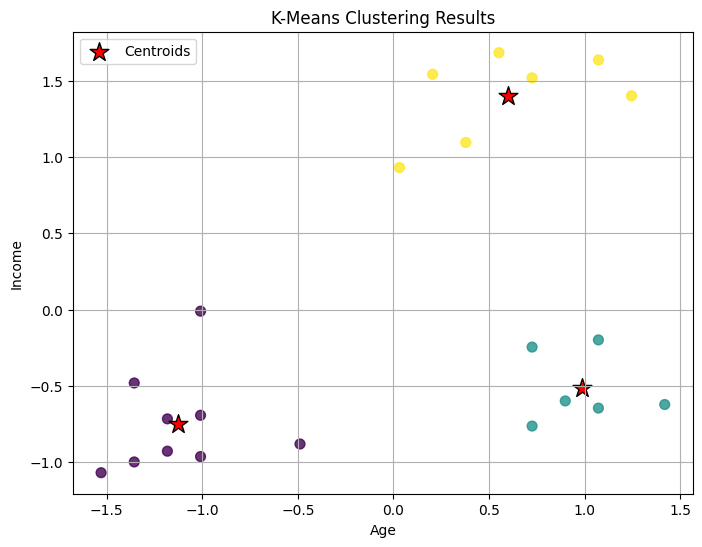

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self, n_clusters=3, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.labels = None

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def fit(self, X):
        X=np.array(X)
        n_samples, n_features = X.shape

        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iter):
            self.labels = self._assign_clusters(X)

            old_centroids = self.centroids.copy()

            self.centroids = self._update_centroids(X, self.labels)

            if np.allclose(self.centroids,old_centroids):
                print(f"Converged after {i+1} iterations.")
                break
        
        return self

    def _assign_clusters(self, X):
        labels = np.zeros(X.shape[0], dtype=int)
        for i, point in enumerate(X):
            distances = [self._euclidean_distance(point, centroid) for centroid in self.centroids]
            labels[i] = np.argmin(distances)
        return labels

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[k] = self.centroids[k]
        return new_centroids

    def predict(self, X):
        X = np.array(X)
        return self._assign_clusters(X)



kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

final_labels = kmeans.labels
final_centroids = kmeans.centroids


plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='*', s=200, label='Centroids', edgecolor='black')
plt.title('K-Means Clustering Results')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.grid(True)
plt.show()